# Checking the results of the grid-search

### Loading the data from disk (as saved by Prepare-training-data)

In [1]:
import xgboost as xgb
import sklearn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve, auc
from scipy.stats import ks_2samp
import pandas as pd

In [2]:
%matplotlib inline
plt.rcParams["figure.figsize"] = (12,6)
from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

In [3]:
def results_dataframe_std(all_results):
    tmp = []
    for k, v in all_results.items():
        line = []
        line += k

        def sample_info(line, v):
            line.append(np.mean(v))
            line.append(np.std(v))

        
        sample_info(line, v[0])

        all_kss = [ r.statistic for r in v[1]]
        sample_info(line, all_kss)

        all_ksb = [ r.statistic for r in v[2]]
        sample_info(line, all_ksb)
        tmp.append(line)
        
    return pd.DataFrame(tmp, columns=["n_estimators", "eta", "max_depth", "auc", "auc_std", "kss", "kss_std", "ksb", "ksb_std"])


def results_dataframe_single(all_results):
    tmp = []
    for k, v in all_results.items():
        line = []
        line += k
        line.append(v[0])
        line.append(v[1].statistic)
        line.append(v[2].statistic)
        tmp.append(line)
    return pd.DataFrame(tmp, columns=["n_estimators", "eta", "max_depth", "auc", "kss", "ksb"])

In [4]:
import pickle
with open("cv_result.pkl", "rb") as f:
    all_results = pickle.load(f)
print(len(all_results))
results_df = results_dataframe_std(all_results)
results_df

450


,n_estimators,eta,max_depth,auc,auc_std,kss,kss_std,ksb,ksb_std
0,100,0.01,2,0.829452,0.000804,0.025647,0.001663,0.002307,0.000297
1,100,0.01,3,0.843752,0.000819,0.029262,0.001968,0.002622,0.000251
2,100,0.01,4,0.848969,0.000193,0.030250,0.001118,0.002439,0.000256
3,100,0.01,5,0.855102,0.000418,0.034487,0.001605,0.002264,0.000172
4,100,0.01,6,0.861148,0.000115,0.043673,0.002535,0.002344,0.000212
...,...,...,...,...,...,...,...,...,...
445,500,0.10,2,0.899246,0.000422,0.037400,0.001320,0.002733,0.000194
446,500,0.10,3,0.902232,0.000558,0.064898,0.001981,0.002815,0.000212
447,500,0.10,4,0.902402,0.000614,0.120879,0.001554,0.003365,0.000165
448,500,0.10,5,0.899738,0.001055,0.209392,0.003940,0.004334,0.000171


In [5]:
#results_df.query("max_depth == 3 and abs(eta - 0.10) < 1e-3")

In [6]:
# import matplotlib as mpl
# cmap = mpl.colormaps['magma']
# norm = mpl.colors.Normalize(min(df['eta']), max(df['eta']))
# colours = [ cmap(norm(e)) for e in df['eta'] ]

def plot_for_n_estimator(results_df, n_estimators, plot_errors=True):

    def plot(md, marker):
        df = results_df.query(f"n_estimators == {n_estimators} & max_depth == {md}").copy()
        #print(df)
        plt.scatter(df.auc, df.kss, c=df.eta, zorder=100, s=80, marker=marker, label=f"max_depth={md}")
        if plot_errors == True:
            plt.errorbar(df.auc, df.kss, xerr=df.auc_std, yerr=df.kss_std, marker=None, fmt='.', c='black', zorder=0, lw=1.0)

    plot(3, ">")
    plot(4, "<")
    plot(5, "s")
    plot(6, "*")
    cbar = plt.colorbar()
    cbar.set_label("eta value")
    plt.ylabel("Kolmogorov-Smirnov statistic of BDT output for signal on test sample vs training")
    plt.xlabel(f"BDT ROC AUC for n_estimators={n_estimators}")
    plt.grid(color='black', linestyle='--', linewidth=0.5)
    plt.legend()
    
    plt.ylim([0, 0.20])
    ticks = plt.yticks()[0]
    plt.yticks(np.arange(min(ticks), max(ticks), 0.01))
    
    plt.xlim([0.840, 0.91])
    ticks = plt.xticks()[0]
    plt.xticks(np.arange(min(ticks), max(ticks), 0.005))
    
#plot_for_n_estimator(n_estimators=100)

In [7]:
#plot_for_n_estimator(n_estimators=150)

In [8]:
#plot_for_n_estimator(n_estimators=200)

In [9]:
#plot_for_n_estimator(n_estimators=250)

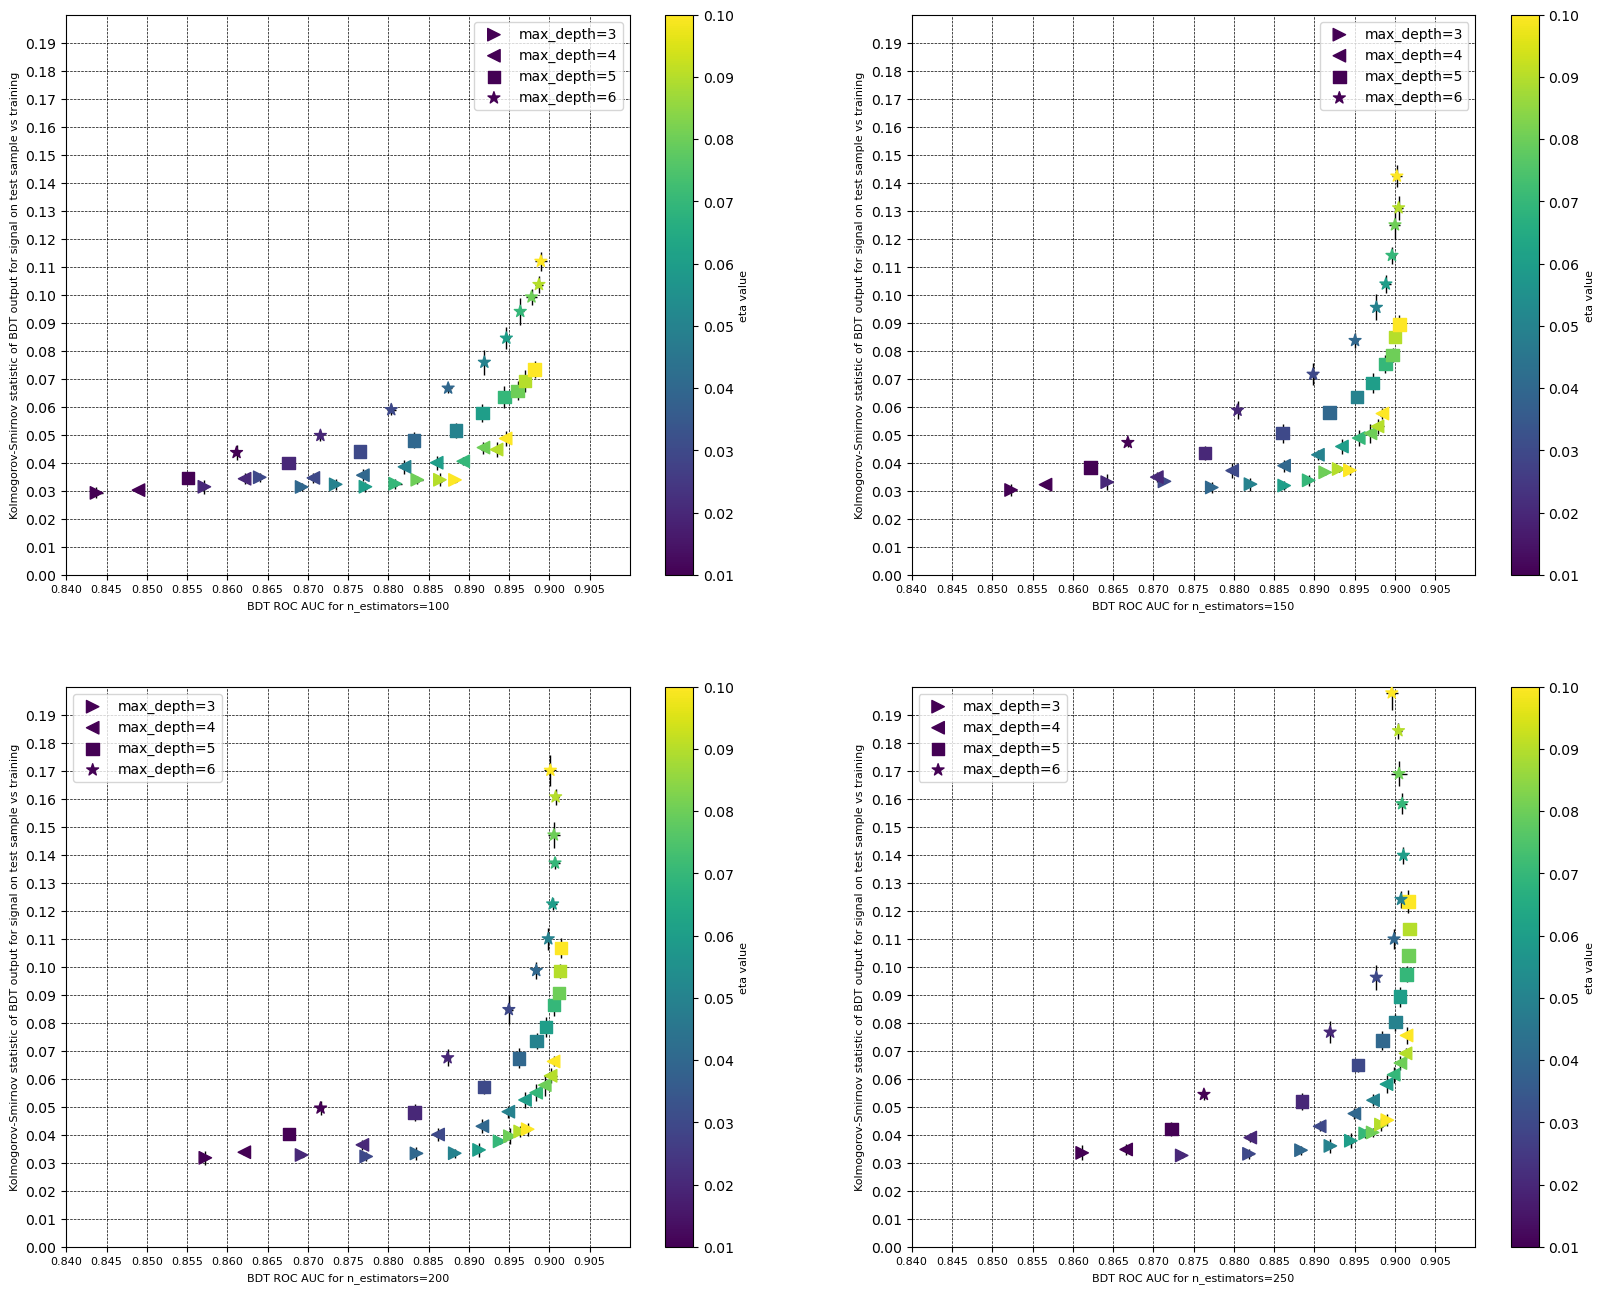

In [10]:
plt.rc('axes', labelsize=8)
plt.rc('xtick', labelsize=8)
fig, axs = plt.subplots(2,2, figsize=(20, 16))
plt.sca(axs[0][0])
plot_for_n_estimator(results_df, n_estimators=100)
plt.sca(axs[0][1])
plot_for_n_estimator(results_df, n_estimators=150)
plt.sca(axs[1][0])
plot_for_n_estimator(results_df, n_estimators=200)
plt.sca(axs[1][1])
plot_for_n_estimator(results_df, n_estimators=250)

In [11]:
import pickle
with open("single_result.pkl", "rb") as f:
    all_results = pickle.load(f)
print(len(all_results))
results_dfs = results_dataframe_single(all_results)
results_dfs

450


,n_estimators,eta,max_depth,auc,kss,ksb
0,100,0.01,2,0.830369,0.028234,0.002116
1,100,0.01,3,0.845495,0.031605,0.002585
2,100,0.01,4,0.849134,0.036355,0.002347
3,100,0.01,5,0.854847,0.039990,0.002468
4,100,0.01,6,0.859819,0.058349,0.002218
...,...,...,...,...,...,...
445,500,0.10,2,0.899350,0.046145,0.003232
446,500,0.10,3,0.901734,0.091662,0.003377
447,500,0.10,4,0.900690,0.166387,0.003593
448,500,0.10,5,0.896919,0.295805,0.005590


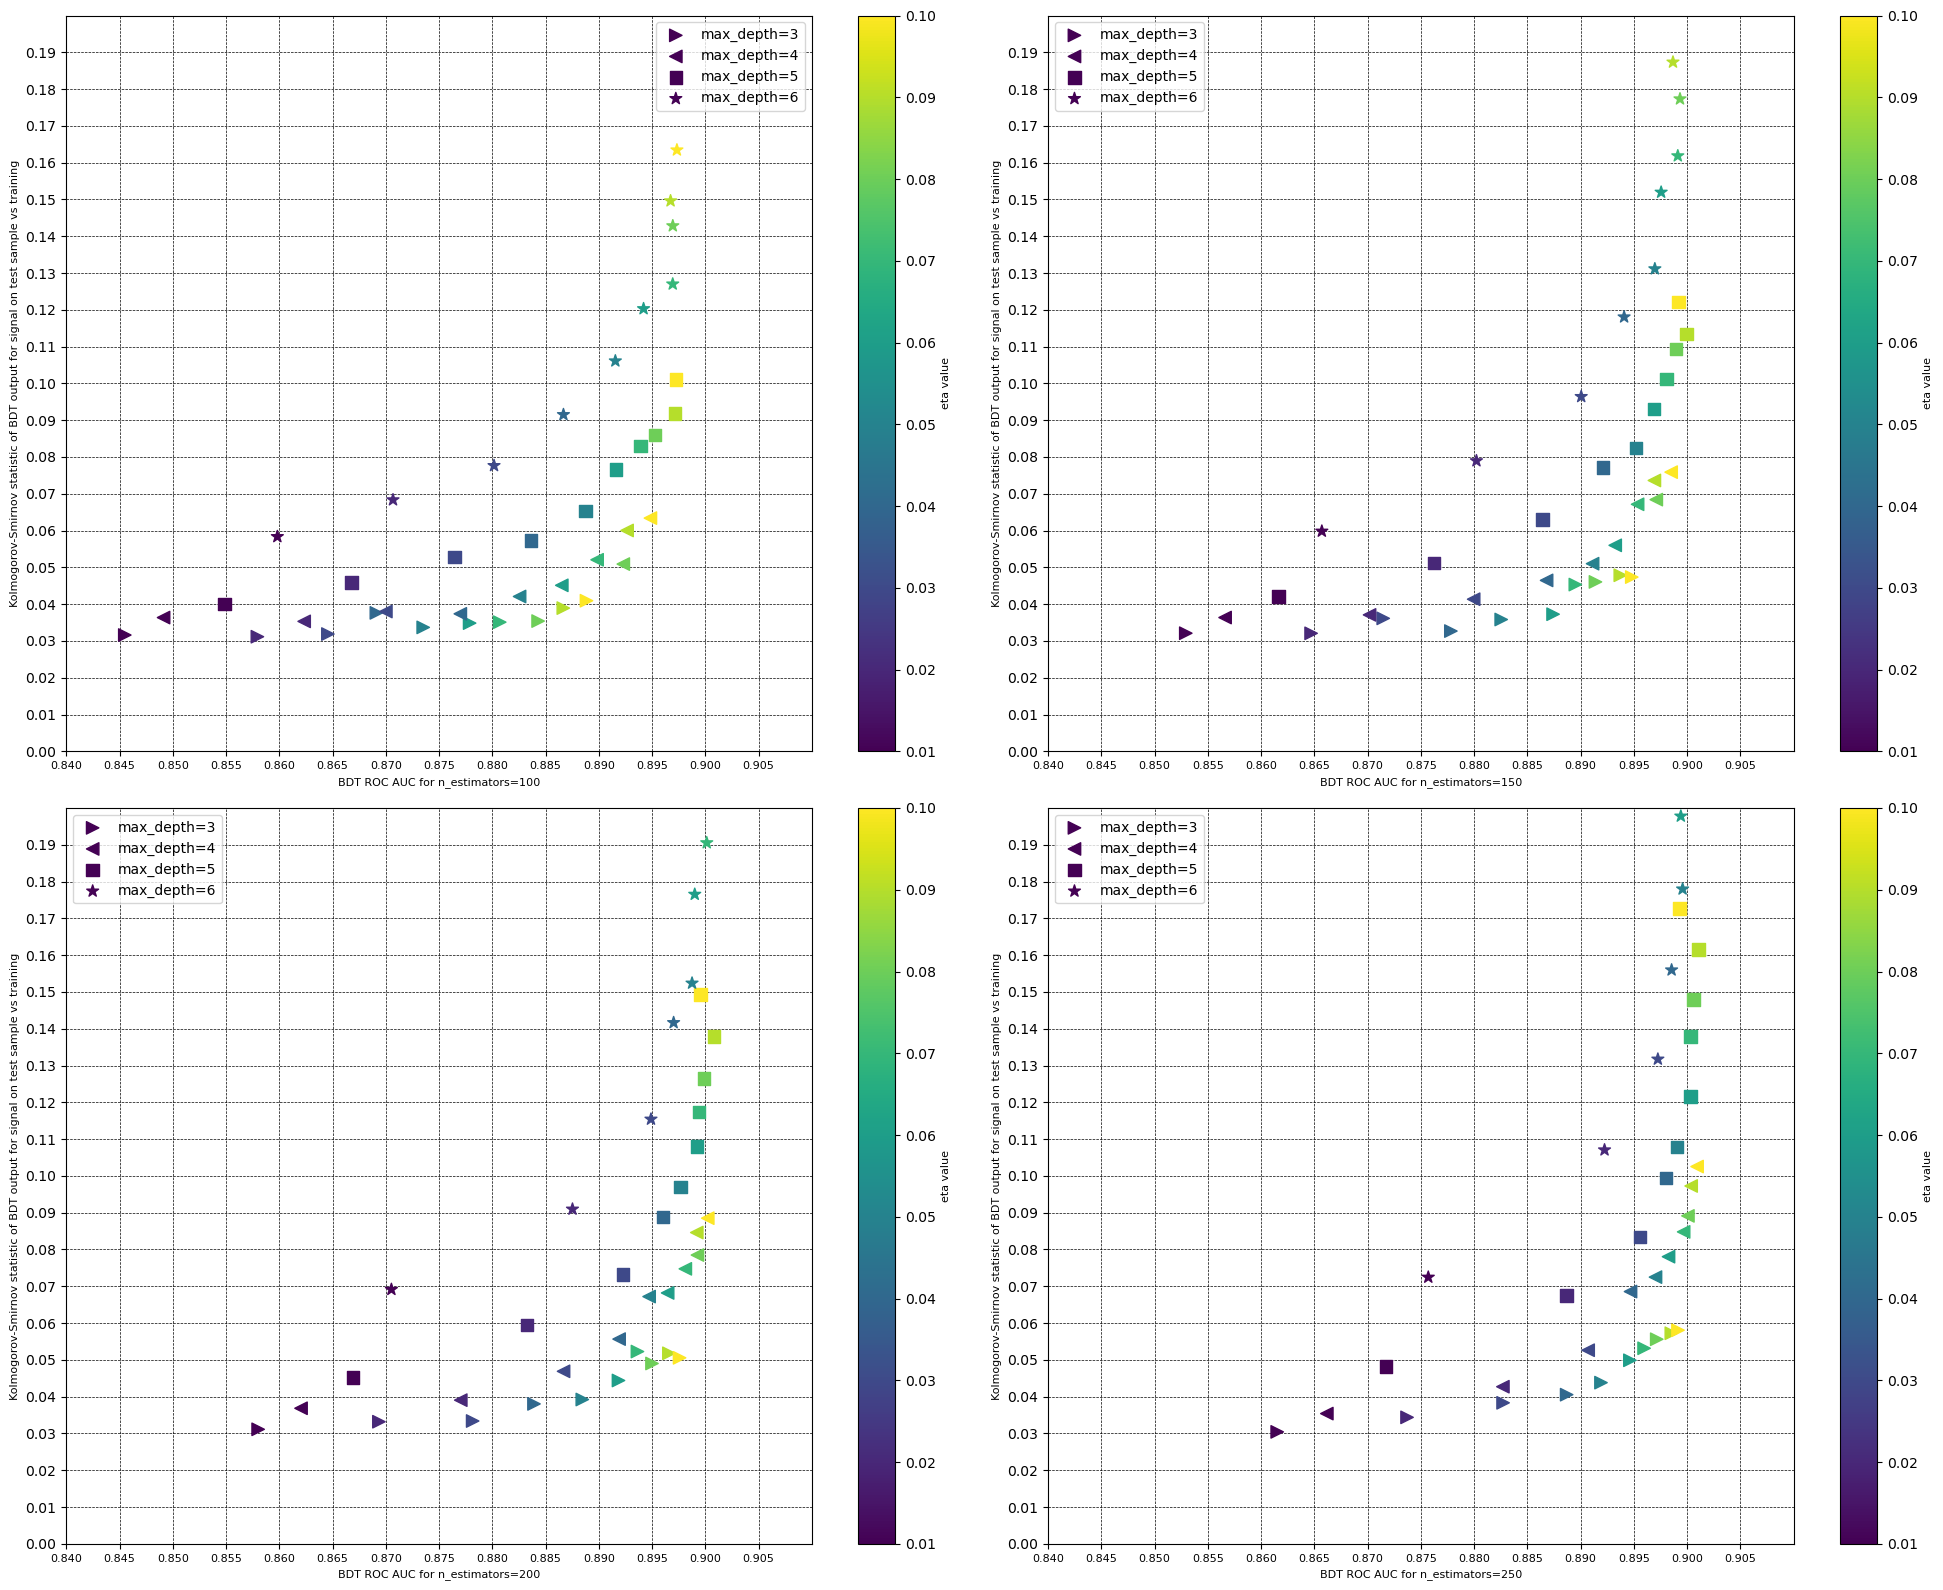

In [15]:
plt.rc('axes', labelsize=8)
plt.rc('xtick', labelsize=8)
fig, axs = plt.subplots(2,2, figsize=(20, 16))
plt.sca(axs[0][0])
plot_for_n_estimator(results_dfs, n_estimators=100, plot_errors=False)
plt.sca(axs[0][1])
plot_for_n_estimator(results_dfs, n_estimators=150, plot_errors=False)
plt.sca(axs[1][0])
plot_for_n_estimator(results_dfs, n_estimators=200, plot_errors=False)
plt.sca(axs[1][1])
plot_for_n_estimator(results_dfs, n_estimators=250, plot_errors=False)
plt.tight_layout()
plt.savefig("bdtdblcharm_tuning.png")